In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

matches = pd.read_csv("matches_clean.csv")
ball_by_ball = pd.read_csv("ball_by_ball_clean.csv")
franchise_rankings = pd.read_csv("franchise_rankings.csv")

In [ ]:
champions = pd.DataFrame({
    "season":[
        2008,2009,2010,2011,2012,
        2013,2014,2015,2016,2017,
        2018,2019,2020,2021,2022,
        2023,2024
    ],

    "champion":[
        "Rajasthan Royals",
        "Deccan Chargers",
        "Chennai Super Kings",
        "Chennai Super Kings",
        "Kolkata Knight Riders",
        "Mumbai Indians",
        "Kolkata Knight Riders",
        "Mumbai Indians",
        "Sunrisers Hyderabad",
        "Mumbai Indians",
        "Chennai Super Kings",
        "Mumbai Indians",
        "Mumbai Indians",
        "Chennai Super Kings",
        "Gujarat Titans",
        "Chennai Super Kings",
        "Kolkata Knight Riders"
    ]
})

In [ ]:
championship_count = (
    champions.groupby("champion")
    .size()
    .reset_index(name="titles")
    .sort_values(
        "titles",
        ascending=False
    )
)

championship_count

,champion,titles
0,Chennai Super Kings,5
4,Mumbai Indians,5
3,Kolkata Knight Riders,3
2,Gujarat Titans,1
1,Deccan Chargers,1
5,Rajasthan Royals,1
6,Sunrisers Hyderabad,1


In [ ]:
ball_by_ball["is_boundary"] = np.where(
    ball_by_ball["boundary_type"] == "Boundary",
    1,
    0
)

In [ ]:
ball_by_ball["is_dot"] = np.where(
    ball_by_ball["ball_result"] == "Dot Ball",
    1,
    0
)

In [ ]:
ball_by_ball["is_wicket"] = np.where(
    ball_by_ball["wicket_status"] == "Wicket",
    1,
    0
)

In [ ]:
team_boundary = (
    ball_by_ball.groupby("batting_team")
    .agg(
        total_balls=("delivery_id","count"),
        boundaries=("is_boundary","sum")
    )
    .reset_index()
)

team_boundary["boundary_percentage"] = round(
    (
        team_boundary["boundaries"]
        /
        team_boundary["total_balls"]
    ) * 100,
    2
)

team_boundary.head()

,batting_team,total_balls,boundaries,boundary_percentage
0,Chennai Super Kings,14704,4611,31.36
1,Deccan Chargers,3716,1147,30.87
2,Delhi Capitals,15307,4760,31.10
3,Gujarat Lions,2043,615,30.10
4,Gujarat Titans,2598,807,31.06


In [ ]:
team_dotballs = (
    ball_by_ball.groupby("bowling_team")
    .agg(
        total_balls=("delivery_id","count"),
        dot_balls=("is_dot","sum")
    )
    .reset_index()
)

team_dotballs["dot_ball_percentage"] = round(
    (
        team_dotballs["dot_balls"]
        /
        team_dotballs["total_balls"]
    ) * 100,
    2
)

team_dotballs.head()

,bowling_team,total_balls,dot_balls,dot_ball_percentage
0,Chennai Super Kings,14045,2174,15.48
1,Deccan Chargers,3936,632,16.06
2,Delhi Capitals,15294,2280,14.91
3,Gujarat Lions,1730,272,15.72
4,Gujarat Titans,2413,390,16.16


In [ ]:
team_wickets = (
    ball_by_ball.groupby("bowling_team")
    .agg(
        total_wickets=("is_wicket","sum")
    )
    .reset_index()
)

team_wickets.head()

,bowling_team,total_wickets
0,Chennai Super Kings,807
1,Deccan Chargers,223
2,Delhi Capitals,803
3,Gujarat Lions,100
4,Gujarat Titans,147


In [ ]:
dna = team_boundary.merge(
    team_dotballs,
    left_on="batting_team",
    right_on="bowling_team",
    how="left"
)

dna = dna.merge(
    team_wickets,
    left_on="batting_team",
    right_on="bowling_team",
    how="left"
)

In [ ]:
dna = dna[
    [
        "batting_team",
        "boundary_percentage",
        "dot_ball_percentage",
        "total_wickets"
    ]
]

dna.columns = [
    "team",
    "boundary_percentage",
    "dot_ball_percentage",
    "total_wickets"
]

dna.head()

,team,boundary_percentage,dot_ball_percentage,total_wickets
0,Chennai Super Kings,31.36,15.48,807
1,Deccan Chargers,30.87,16.06,223
2,Delhi Capitals,31.10,14.91,803
3,Gujarat Lions,30.10,15.72,100
4,Gujarat Titans,31.06,16.16,147


In [ ]:
dna = dna.merge(
    championship_count,
    left_on="team",
    right_on="champion",
    how="left"
)

dna["titles"] = dna["titles"].fillna(0)

dna.drop(
    columns=["champion"],
    inplace=True
)

dna.head()

,team,boundary_percentage,dot_ball_percentage,total_wickets,titles
0,Chennai Super Kings,31.36,15.48,807,5.0
1,Deccan Chargers,30.87,16.06,223,1.0
2,Delhi Capitals,31.10,14.91,803,0.0
3,Gujarat Lions,30.10,15.72,100,0.0
4,Gujarat Titans,31.06,16.16,147,1.0


In [ ]:
dna["team_category"] = np.where(
    dna["titles"] > 0,
    "Champion",
    "Non-Champion"
)

In [ ]:
dna_summary = (
    dna.groupby("team_category")
    .agg(
        avg_boundary_pct=("boundary_percentage","mean"),
        avg_dotball_pct=("dot_ball_percentage","mean"),
        avg_wickets=("total_wickets","mean"),
        avg_titles=("titles","mean")
    )
    .round(2)
)

dna_summary

,avg_boundary_pct,avg_dotball_pct,avg_wickets,avg_titles
team_category,,,,
Champion,31.27,15.40,609.57,2.43
Non-Champion,31.18,14.98,388.38,0.00


In [ ]:
dna["aggression_index"] = round(
    dna["boundary_percentage"] * 1.5,
    2
)

In [ ]:
dna["bowling_dominance"] = round(
    (
        dna["dot_ball_percentage"] * 0.6
        +
        dna["total_wickets"] * 0.4
    ),
    2
)

In [ ]:
dna["dna_score"] = round(
    (
        dna["aggression_index"] * 0.4
        +
        dna["bowling_dominance"] * 0.6
    ),
    2
)

In [ ]:
dna_rankings = dna.sort_values(
    "dna_score",
    ascending=False
)

dna_rankings.reset_index(
    drop=True,
    inplace=True
)

dna_rankings.head(10)

,team,boundary_percentage,dot_ball_percentage,total_wickets,titles,team_category,aggression_index,bowling_dominance,dna_score
0,Mumbai Indians,31.95,14.58,909,5.0,Champion,47.92,372.35,242.58
1,Royal Challengers Bengaluru,31.22,14.82,872,0.0,Non-Champion,46.83,357.69,233.35
2,Punjab Kings,31.63,14.98,865,0.0,Non-Champion,47.44,354.99,231.97
3,Kolkata Knight Riders,31.89,15.39,828,3.0,Champion,47.84,340.43,223.39
4,Chennai Super Kings,31.36,15.48,807,5.0,Champion,47.04,332.09,218.07
5,Delhi Capitals,31.10,14.91,803,0.0,Non-Champion,46.65,330.15,216.75
6,Rajasthan Royals,31.13,14.74,752,1.0,Champion,46.70,309.64,204.46
7,Sunrisers Hyderabad,30.63,15.37,601,1.0,Champion,45.94,249.62,168.15
8,Deccan Chargers,30.87,16.06,223,1.0,Champion,46.30,98.84,77.82
9,Lucknow Super Giants,32.11,13.98,157,0.0,Non-Champion,48.16,71.19,61.98


In [ ]:
TEAM_COLORS = {
    "Chennai Super Kings": "#FFFF00",
    "Mumbai Indians": "#004BA0",
    "Royal Challengers Bangalore": "#EC1C24",
    "Kolkata Knight Riders": "#3A225D",
    "Sunrisers Hyderabad": "#FF822A",
    "Delhi Daredevils": "#17449B",
    "Delhi Capitals": "#17449B",
    "Rajasthan Royals": "#FF69B4",
    "Kings XI Punjab": "#D71920",
    "Punjab Kings": "#D71920",
    "Gujarat Titans": "#1B2133",
    "Lucknow Super Giants": "#00AEEF",
    "Deccan Chargers": "#1E88E5",
    "Pune Warriors India": "#5E35B1"
}

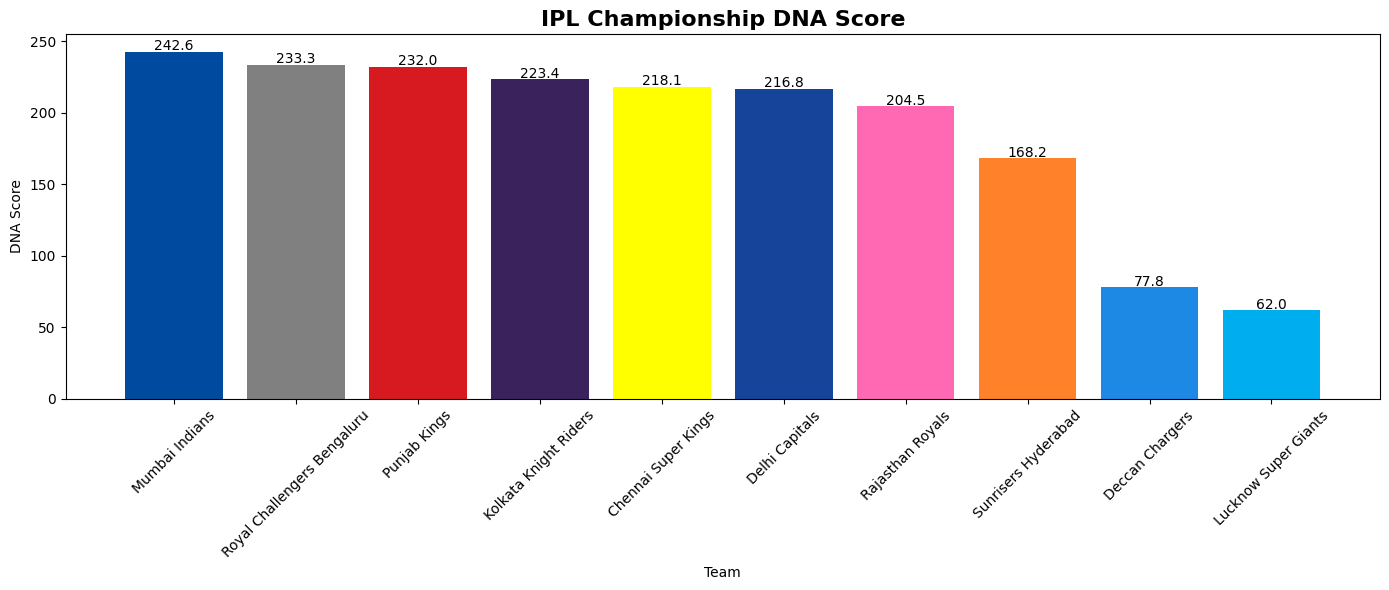

In [ ]:
top10 = dna_rankings.head(10)

colors = [
    TEAM_COLORS.get(team, "#808080")
    for team in top10["team"]
]

plt.figure(figsize=(14,6))

bars = plt.bar(
    top10["team"],
    top10["dna_score"],
    color=colors
)

plt.title(
    "IPL Championship DNA Score",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Team")
plt.ylabel("DNA Score")

plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+1,
        f"{bar.get_height():.1f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
dna_rankings.to_csv(
    "championship_dna_rankings.csv",
    index=False
)

In [ ]:
final_dna_rankings = dna_rankings[
    [
        "team",
        "titles",
        "boundary_percentage",
        "dot_ball_percentage",
        "total_wickets",
        "aggression_index",
        "bowling_dominance",
        "dna_score"
    ]
]

final_dna_rankings.head(10)

,team,titles,boundary_percentage,dot_ball_percentage,total_wickets,aggression_index,bowling_dominance,dna_score
0,Mumbai Indians,5.0,31.95,14.58,909,47.92,372.35,242.58
1,Royal Challengers Bengaluru,0.0,31.22,14.82,872,46.83,357.69,233.35
2,Punjab Kings,0.0,31.63,14.98,865,47.44,354.99,231.97
3,Kolkata Knight Riders,3.0,31.89,15.39,828,47.84,340.43,223.39
4,Chennai Super Kings,5.0,31.36,15.48,807,47.04,332.09,218.07
5,Delhi Capitals,0.0,31.10,14.91,803,46.65,330.15,216.75
6,Rajasthan Royals,1.0,31.13,14.74,752,46.70,309.64,204.46
7,Sunrisers Hyderabad,1.0,30.63,15.37,601,45.94,249.62,168.15
8,Deccan Chargers,1.0,30.87,16.06,223,46.30,98.84,77.82
9,Lucknow Super Giants,0.0,32.11,13.98,157,48.16,71.19,61.98
